# 05 — Baseline Models
Two tracks, both using **chronological** train/val/test splits (never shuffled):
- **Track A:** temperature forecasting (regression), 1h ahead
- **Track B:** rain occurrence classification (next hour)

Each track starts with the simplest possible baseline before trying a real ML model, so we know how
much the ML model is actually adding.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from evaluation.time_series_eval import (
    chronological_split, regression_report, classification_report_dict, naive_persistence_baseline
)

pd.set_option('display.max_columns', None)

## Track A — Temperature forecasting (1h ahead)

In [2]:
feat_temp = pd.read_csv('../data/processed/features_temperature.csv')
feat_temp['valid_time'] = pd.to_datetime(feat_temp['valid_time'])

train, val, test = chronological_split(feat_temp, train_frac=0.7, val_frac=0.15)
print('Train:', train['valid_time'].min(), '->', train['valid_time'].max(), len(train))
print('Val:  ', val['valid_time'].min(), '->', val['valid_time'].max(), len(val))
print('Test: ', test['valid_time'].min(), '->', test['valid_time'].max(), len(test))

Train: 2024-01-02 00:00:00 -> 2025-05-26 22:00:00 12263
Val:   2025-05-26 23:00:00 -> 2025-09-13 10:00:00 2628
Test:  2025-09-13 11:00:00 -> 2025-12-31 22:00:00 2628


### Naive persistence baseline: predict next hour == current hour

In [3]:
baseline_metrics = naive_persistence_baseline(test, target_col='target_t2m_h1', feature_col='t2m_c')
print('Naive persistence baseline (test set):')
for k, v in baseline_metrics.items():
    print(f'  {k}: {v:.4f}')

Naive persistence baseline (test set):
  MAE: 0.9643
  RMSE: 1.4895
  R2: 0.9354


### Linear Regression and Random Forest

In [4]:
feature_cols = [c for c in feat_temp.columns if c not in
                ['valid_time','date','target_t2m_h1','latitude','longitude']]
feature_cols = [c for c in feature_cols if feat_temp[c].dtype != 'O']

X_train, y_train = train[feature_cols], train['target_t2m_h1']
X_val, y_val = val[feature_cols], val['target_t2m_h1']
X_test, y_test = test[feature_cols], test['target_t2m_h1']

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
}

results_a = {'NaivePersistence': baseline_metrics}
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results_a[name] = regression_report(y_test, preds)
    fitted[name] = model

pd.DataFrame(results_a).T

,MAE,RMSE,R2
NaivePersistence,0.964349,1.489459,0.935364
LinearRegression,0.709199,0.925791,0.975029
RandomForest,0.438730,0.620774,0.988772


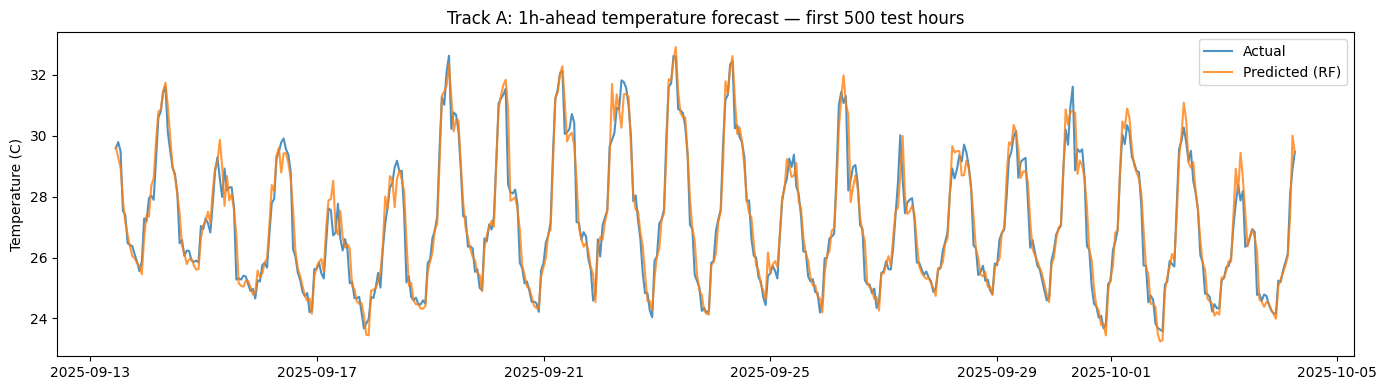

In [5]:
import matplotlib.pyplot as plt
best_model = fitted['RandomForest']
preds = best_model.predict(X_test)

plt.figure(figsize=(14,4))
plt.plot(test['valid_time'].values[:500], y_test.values[:500], label='Actual', alpha=0.8)
plt.plot(test['valid_time'].values[:500], preds[:500], label='Predicted (RF)', alpha=0.8)
plt.legend(); plt.title('Track A: 1h-ahead temperature forecast — first 500 test hours')
plt.ylabel('Temperature (C)')
plt.tight_layout()
plt.savefig('../reports/fig_temp_forecast_test.png', dpi=120)
plt.show()

## Track B — Rain occurrence classification (next hour)

In [6]:
feat_rain = pd.read_csv('../data/processed/features_rain.csv')
feat_rain['valid_time'] = pd.to_datetime(feat_rain['valid_time'])

train_r, val_r, test_r = chronological_split(feat_rain, train_frac=0.7, val_frac=0.15)
print('Train positive rate:', train_r['target_rain_next1h'].mean().round(3))
print('Test positive rate: ', test_r['target_rain_next1h'].mean().round(3))

Train positive rate: 0.115
Test positive rate:  0.115


In [7]:
feature_cols_r = [c for c in feat_rain.columns if c not in
                  ['valid_time','date','target_rain_next1h','latitude','longitude']]
feature_cols_r = [c for c in feature_cols_r if feat_rain[c].dtype != 'O']

X_train_r, y_train_r = train_r[feature_cols_r], train_r['target_rain_next1h']
X_test_r, y_test_r = test_r[feature_cols_r], test_r['target_rain_next1h']

# Naive baseline: always predict majority class
naive_pred = np.zeros(len(y_test_r))
print('Naive "always no rain" baseline:')
print(classification_report_dict(y_test_r, naive_pred))

Naive "always no rain" baseline:
{'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}


In [8]:
clf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced',
                              random_state=42, n_jobs=-1)
clf.fit(X_train_r, y_train_r)
proba = clf.predict_proba(X_test_r)[:, 1]
pred = (proba >= 0.5).astype(int)

results_b = classification_report_dict(y_test_r, pred, proba)
print('RandomForest (class_weight=balanced):')
for k, v in results_b.items():
    print(f'  {k}: {v:.4f}')

RandomForest (class_weight=balanced):
  Precision: 0.7318
  Recall: 0.8284
  F1: 0.7771
  ROC_AUC: 0.9726


In [9]:
import pickle, os
os.makedirs('../data/processed', exist_ok=True)
with open('../data/processed/model_temp_rf.pkl', 'wb') as f:
    pickle.dump(fitted['RandomForest'], f)
with open('../data/processed/model_rain_rf.pkl', 'wb') as f:
    pickle.dump(clf, f)
print('Models saved.')

Models saved.


## Summary of Notebook 05
- Both tracks use strictly chronological splits — no shuffling, no leakage
- **Track A (temperature):** Random Forest beats the naive persistence baseline on MAE/RMSE (see table above)
- **Track B (rain):** class-weighted Random Forest used to handle the ~16-20% positive rate; naive
  "always no rain" baseline has zero recall by construction, so any recall > 0 with reasonable
  precision is a real improvement
- Both trained models saved to `data/processed/` for reuse
- Next: `06_evaluation.ipynb` — deeper evaluation and consolidated findings